In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\workstation\Desktop\jdk\row data\shopify_sales_dataset_ml_eda-selected-columns.csv")

In [3]:
df.head(10)

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media
5,6,2023-03-13,29596,2796,Beauty,444.14,0,5,UAE,Social Media
6,7,2024-12-01,11896,6012,Accessories,244.18,15,1,Canada,Social Media
7,8,2023-01-21,43857,4248,Beauty,457.16,25,1,USA,Email
8,9,2024-09-06,10308,3966,Fashion,394.28,15,1,India,Direct
9,10,2023-05-02,35168,7180,Electronics,363.69,30,2,UAE,Social Media


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
dtypes: float64(1), int64(5), object(4)
memory usage: 4.6+ MB


In [5]:
df.dtypes

order_id              int64
order_date           object
customer_id           int64
product_id            int64
product_category     object
product_price       float64
discount_percent      int64
quantity              int64
customer_country     object
traffic_source       object
dtype: object

In [6]:
df['order_date']=pd.to_datetime(df['order_date'])

In [7]:
df.dtypes

order_id                     int64
order_date          datetime64[ns]
customer_id                  int64
product_id                   int64
product_category            object
product_price              float64
discount_percent             int64
quantity                     int64
customer_country            object
traffic_source              object
dtype: object

In [8]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_id          0
product_category    0
product_price       0
discount_percent    0
quantity            0
customer_country    0
traffic_source      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['year']=df['order_date'].dt.year
df['month']=df['order_date'].dt.month
df['day']=df['order_date'].dt.day

In [11]:
df.head(10)

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,year,month,day
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,2023,4,13
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,2024,3,11
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,2025,5,10
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,2023,9,28
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,2023,4,17
5,6,2023-03-13,29596,2796,Beauty,444.14,0,5,UAE,Social Media,2023,3,13
6,7,2024-12-01,11896,6012,Accessories,244.18,15,1,Canada,Social Media,2024,12,1
7,8,2023-01-21,43857,4248,Beauty,457.16,25,1,USA,Email,2023,1,21
8,9,2024-09-06,10308,3966,Fashion,394.28,15,1,India,Direct,2024,9,6
9,10,2023-05-02,35168,7180,Electronics,363.69,30,2,UAE,Social Media,2023,5,2


In [12]:
df['discount_percent']=df['discount_percent']/100

In [13]:
df.head(10)

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,year,month,day
0,1,2023-04-13,14958,7824,Accessories,143.39,0.40,1,USA,Paid Ads,2023,4,13
1,2,2024-03-11,26825,5557,Sports,746.49,0.15,4,UAE,Email,2024,3,11
2,3,2025-05-10,37450,2225,Electronics,641.06,0.05,5,Canada,Paid Ads,2025,5,10
3,4,2023-09-28,20691,7855,Footwear,512.39,0.00,3,UAE,Direct,2023,9,28
4,5,2023-04-17,24631,7789,Sports,415.89,0.25,3,UAE,Social Media,2023,4,17
5,6,2023-03-13,29596,2796,Beauty,444.14,0.00,5,UAE,Social Media,2023,3,13
6,7,2024-12-01,11896,6012,Accessories,244.18,0.15,1,Canada,Social Media,2024,12,1
7,8,2023-01-21,43857,4248,Beauty,457.16,0.25,1,USA,Email,2023,1,21
8,9,2024-09-06,10308,3966,Fashion,394.28,0.15,1,India,Direct,2024,9,6
9,10,2023-05-02,35168,7180,Electronics,363.69,0.30,2,UAE,Social Media,2023,5,2


In [14]:
df['total_price']=df['product_price']*df['quantity']

In [15]:
df['discound_value']=df['total_price']*df['discount_percent']

In [16]:
df['net_sales']=df['total_price']-df['discound_value']

In [17]:
df.head(10)

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,year,month,day,total_price,discound_value,net_sales
0,1,2023-04-13,14958,7824,Accessories,143.39,0.40,1,USA,Paid Ads,2023,4,13,143.39,57.3560,86.0340
1,2,2024-03-11,26825,5557,Sports,746.49,0.15,4,UAE,Email,2024,3,11,2985.96,447.8940,2538.0660
2,3,2025-05-10,37450,2225,Electronics,641.06,0.05,5,Canada,Paid Ads,2025,5,10,3205.30,160.2650,3045.0350
3,4,2023-09-28,20691,7855,Footwear,512.39,0.00,3,UAE,Direct,2023,9,28,1537.17,0.0000,1537.1700
4,5,2023-04-17,24631,7789,Sports,415.89,0.25,3,UAE,Social Media,2023,4,17,1247.67,311.9175,935.7525
5,6,2023-03-13,29596,2796,Beauty,444.14,0.00,5,UAE,Social Media,2023,3,13,2220.70,0.0000,2220.7000
6,7,2024-12-01,11896,6012,Accessories,244.18,0.15,1,Canada,Social Media,2024,12,1,244.18,36.6270,207.5530
7,8,2023-01-21,43857,4248,Beauty,457.16,0.25,1,USA,Email,2023,1,21,457.16,114.2900,342.8700
8,9,2024-09-06,10308,3966,Fashion,394.28,0.15,1,India,Direct,2024,9,6,394.28,59.1420,335.1380
9,10,2023-05-02,35168,7180,Electronics,363.69,0.30,2,UAE,Social Media,2023,5,2,727.38,218.2140,509.1660


In [18]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_id,60000.0,30000.5,1.0,15000.75,30000.5,45000.25,60000.0,17320.652413
order_date,60000,2024-03-25 20:22:06.240000,2023-01-01 00:00:00,2023-08-13 00:00:00,2024-03-27 00:00:00,2024-11-05 00:00:00,2025-06-18 00:00:00,NaN
customer_id,60000.0,30035.0756,10000.0,20037.75,30079.0,40036.25,49999.0,11540.753215
product_id,60000.0,4504.73865,1000.0,2751.75,4503.5,6257.0,7999.0,2018.287018
product_price,60000.0,403.427068,5.01,203.16,403.855,603.135,799.99,230.045257
discount_percent,60000.0,0.181515,0.0,0.05,0.2,0.3,0.4,0.125277
quantity,60000.0,3.009567,1.0,2.0,3.0,4.0,5.0,1.414794
year,60000.0,2023.7843,2023.0,2023.0,2024.0,2024.0,2025.0,0.738884
month,60000.0,5.905667,1.0,3.0,5.0,9.0,12.0,3.407794
day,60000.0,15.658933,1.0,8.0,16.0,23.0,31.0,8.798274


In [19]:
total_sales=df['net_sales'].sum()
print(round(total_sales,2))

59645940.31


In [20]:
total_orders=df['order_id'].nunique()
print(total_orders)

60000


In [21]:
Average_Order_Value=total_sales/total_orders
print(round(Average_Order_Value,2))

994.1


In [22]:
total_quantity=df['quantity'].sum()
print(total_quantity)

180574


In [23]:
sales_by_year=round(df[['year','net_sales']].groupby('year').sum().reset_index(),2)
sales_by_year

,year,net_sales
0,2023,24116736.76
1,2024,24227621.97
2,2025,11301581.59


In [24]:
df['year'].dtype

dtype('int32')

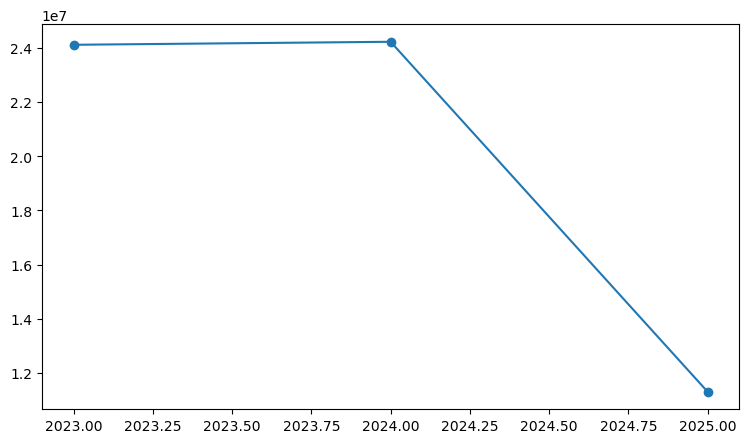

In [25]:
plt.figure(figsize=(9,5))
plt.plot(sales_by_year['year'],sales_by_year['net_sales'],'-o')
plt.show()

In [26]:
sales_by_category=round(df[['product_category','net_sales']].groupby('product_category').sum().reset_index().sort_values(by='net_sales',ascending=False),2)
sales_by_category

,product_category,net_sales
2,Electronics,8717301.73
0,Accessories,8609172.33
5,Home Decor,8545840.66
1,Beauty,8544882.79
3,Fashion,8445073.12
6,Sports,8434699.89
4,Footwear,8348969.80


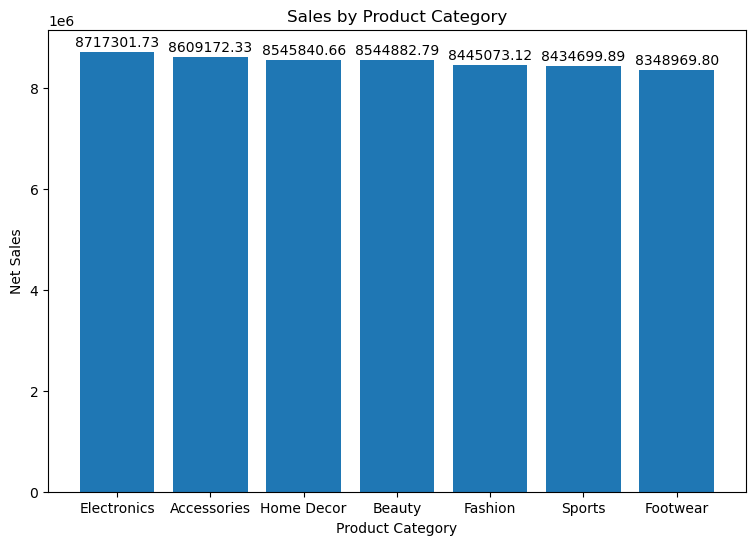

In [27]:
plt.figure(figsize=(9,6))
bars=plt.bar(x=sales_by_category['product_category'],height=sales_by_category['net_sales'])
plt.bar_label(bars, fmt='%.2f', padding=2)

plt.xlabel('Product Category')
plt.ylabel('Net Sales')
plt.title('Sales by Product Category')
plt.show()

In [28]:
Sales_by_Region=round(df[['customer_country','net_sales']].groupby('customer_country').sum().reset_index().sort_values(by='net_sales',ascending=False),2)
Sales_by_Region

,customer_country,net_sales
0,Australia,8698941.21
2,Germany,8566996.16
4,UAE,8541234.78
3,India,8509139.84
1,Canada,8506629.74
6,USA,8450979.21
5,UK,8372019.36


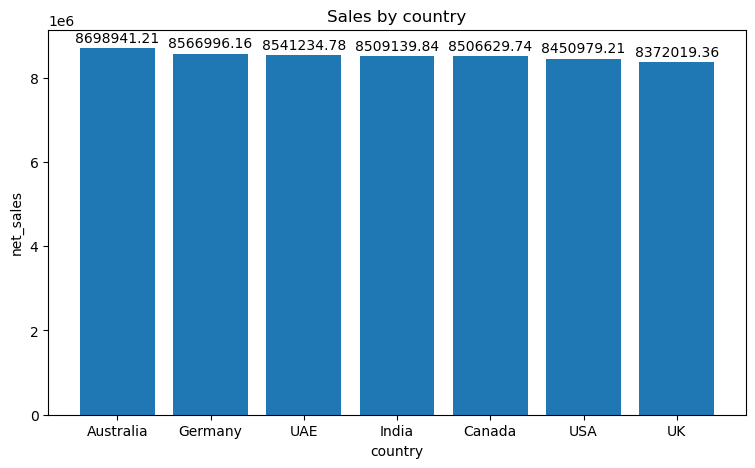

In [29]:
plt.figure(figsize=(9,5))
bars=plt.bar(x=Sales_by_Region['customer_country'],height=Sales_by_Region['net_sales'])
plt.bar_label(bars,fmt='%.2f',padding=2,)
plt.title('Sales by country')
plt.xlabel('country')
plt.ylabel('net_sales')
plt.show()

In [30]:
total_customer=df['customer_id'].nunique()
print(total_customer)

31154


In [31]:
Average_orders_customer=total_sales/total_customer
print(Average_orders_customer)

1914.5515925081852


In [35]:
category_df=df[['product_category','quantity','net_sales']].groupby('product_category').agg({'quantity':'sum',
                                                                                'net_sales':'sum'}).sort_values(by=['net_sales','quantity'],ascending=False)

In [36]:
category_df['net_sales']=round(category_df['net_sales'],3)

In [37]:
category_df

,quantity,net_sales
product_category,,
Electronics,26075,8717301.726
Accessories,26060,8609172.332
Home Decor,25907,8545840.659
Beauty,25757,8544882.789
Fashion,25925,8445073.116
Sports,25500,8434699.889
Footwear,25350,8348969.801


In [134]:
customer_df = (
    df[['customer_id', 'order_id', 'quantity', 'net_sales', 'product_category','order_date']]
    .groupby('customer_id')
    .agg(
        total_quantity=('quantity', 'sum'),
        total_spent=('net_sales', 'sum'),
        
        total_orders=('order_id', 'nunique'),
        category_prefer=('product_category', lambda x: x.mode()[0] if not x.mode().empty else None),
        recency=("order_date", lambda x: (df["order_date"].max() - x.max()).days)
        

    )
    .sort_values(
        by=['total_spent', 'total_quantity', 'total_orders'],
        ascending=False
    )
)

In [135]:
customer_df["average_order_value"] = (
    customer_df["total_spent"] / customer_df["total_orders"]
)

In [136]:
customer_df.head(10)

,total_quantity,total_spent,total_orders,category_prefer,recency,average_order_value
customer_id,,,,,,
40873,26,12955.0655,7,Home Decor,102,1850.723643
27889,23,12462.8120,6,Electronics,137,2077.135333
15933,24,11917.5365,6,Electronics,17,1986.256083
34270,25,11654.9850,5,Accessories,13,2330.997000
24933,19,11362.3775,6,Footwear,110,1893.729583
28605,24,11282.7165,7,Fashion,174,1611.816643
16198,22,10957.5540,5,Beauty,237,2191.510800
33354,24,10696.6490,6,Electronics,196,1782.774833
43578,17,10245.5450,4,Accessories,258,2561.386250


In [137]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_quantity,31154.0,5.796174,3.692589,1.000,3.00000,5.00000,8.000000,28.0000
total_spent,31154.0,1914.551593,1524.748823,3.534,720.96675,1570.02100,2731.504500,12955.0655
total_orders,31154.0,1.925916,1.034863,1.000,1.00000,2.00000,2.000000,8.0000
recency,31154.0,341.122520,246.755569,0.000,129.00000,296.00000,524.000000,899.0000
average_order_value,31154.0,993.369982,656.356499,3.534,494.39775,882.51975,1356.203937,3999.5000


In [138]:
customer_df.corr(numeric_only=True)

,total_quantity,total_spent,total_orders,recency,average_order_value
total_quantity,1.000000,0.800622,0.848528,-0.335236,0.272866
total_spent,0.800622,1.000000,0.678865,-0.267038,0.649717
total_orders,0.848528,0.678865,1.000000,-0.388984,0.002067
recency,-0.335236,-0.267038,-0.388984,1.000000,-0.003925
average_order_value,0.272866,0.649717,0.002067,-0.003925,1.000000


In [139]:
cols=['total_quantity','total_spent','total_orders','recency','average_order_value']

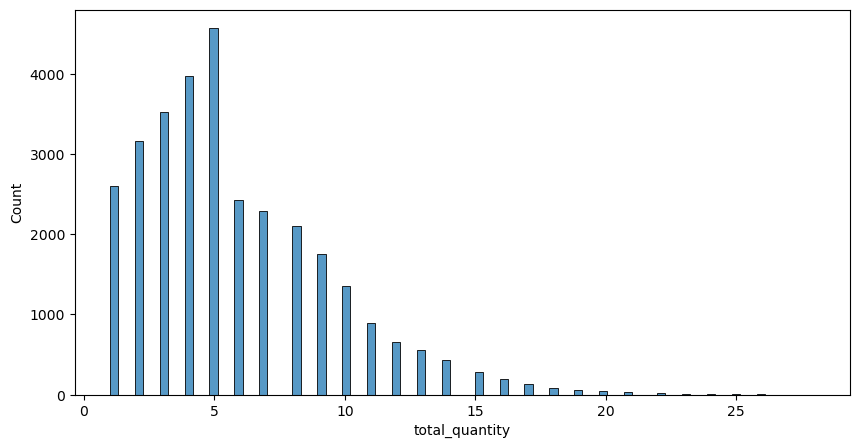

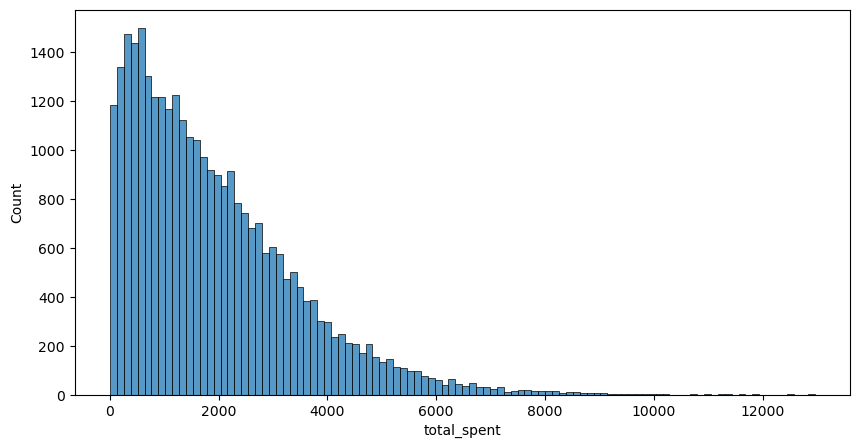

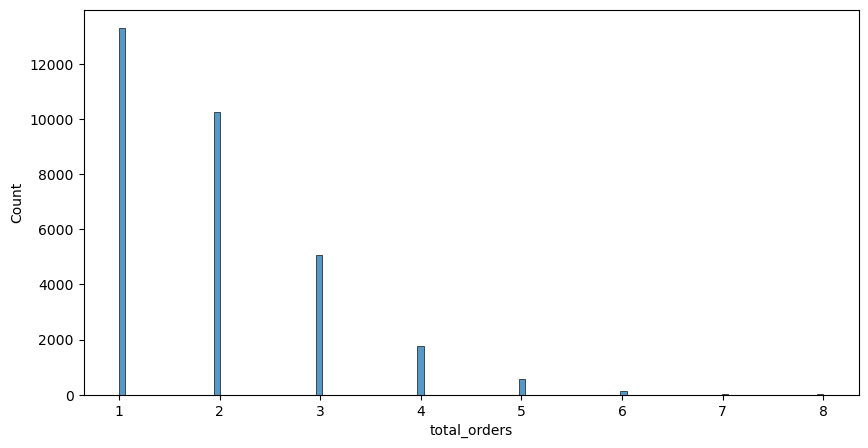

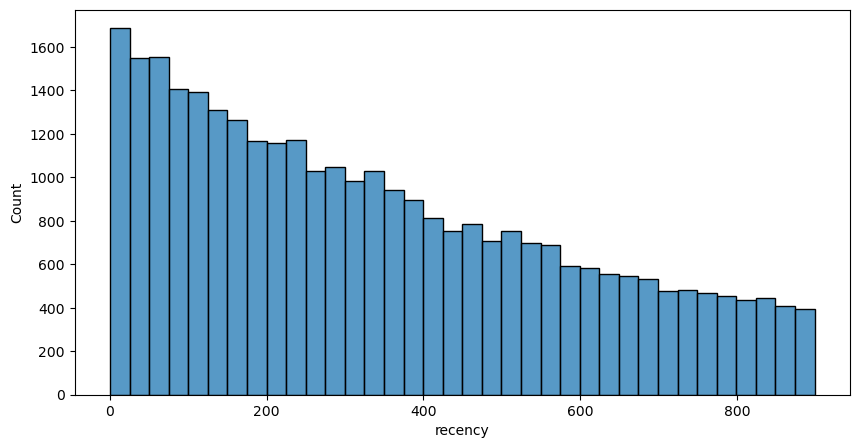

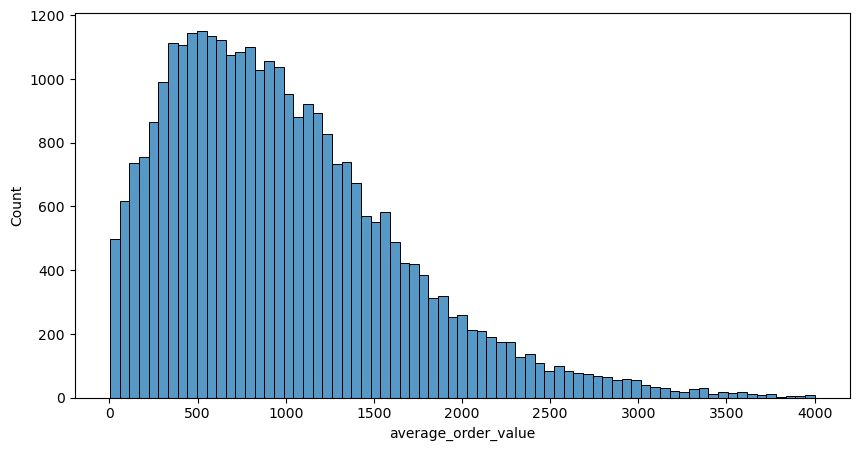

In [140]:
for i in cols:
    plt.figure(figsize=(10,5))
    sns.histplot(customer_df[i])

In [141]:
log_features = [
    "total_orders",
    "total_spent",
    "total_quantity",
    "average_order_value"
]

for col in log_features:
    customer_df_log[col] = np.log1p(customer_df[col])

In [142]:
customer_df_log

,total_orders,total_spent,total_quantity,average_order_value,recency
customer_id,,,,,
40873,2.079442,9.469319,3.295837,7.523872,4.634729
27889,1.945910,9.430585,3.178054,7.639226,4.927254
15933,1.945910,9.385850,3.218876,7.594510,2.890372
34270,1.791759,9.363575,3.258097,7.754480,2.639057
24933,1.945910,9.338151,2.995732,7.546831,4.709530
...,...,...,...,...,...
39429,0.693147,1.923518,0.693147,1.923518,6.302619
31108,0.693147,1.746501,0.693147,1.746501,5.267858
48652,0.693147,1.661556,0.693147,1.661556,5.910797


In [143]:
customer_df.head()

,total_quantity,total_spent,total_orders,category_prefer,recency,average_order_value
customer_id,,,,,,
40873,26,12955.0655,7,Home Decor,102,1850.723643
27889,23,12462.8120,6,Electronics,137,2077.135333
15933,24,11917.5365,6,Electronics,17,1986.256083
34270,25,11654.9850,5,Accessories,13,2330.997000
24933,19,11362.3775,6,Footwear,110,1893.729583


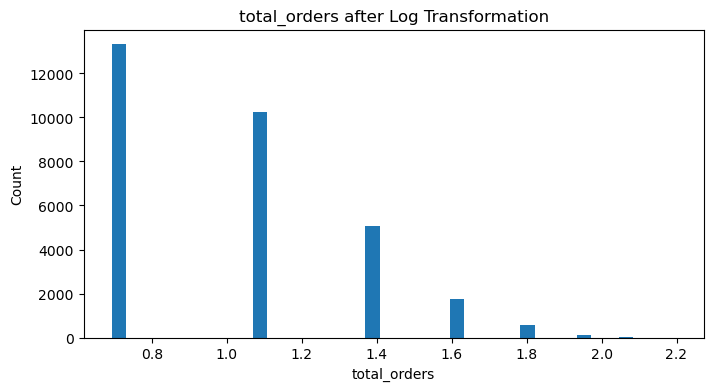

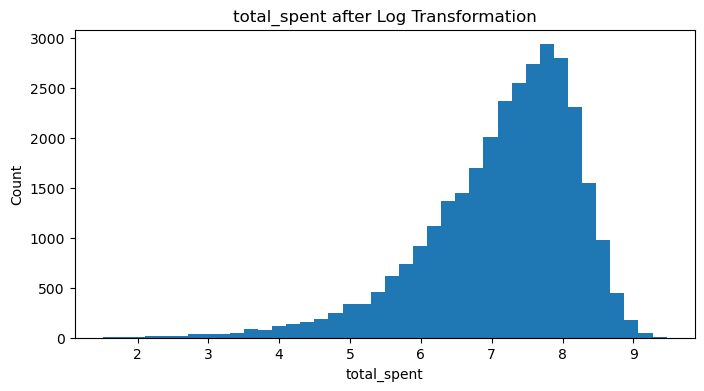

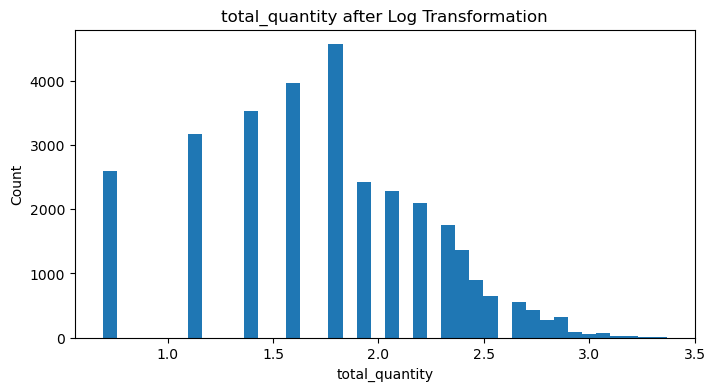

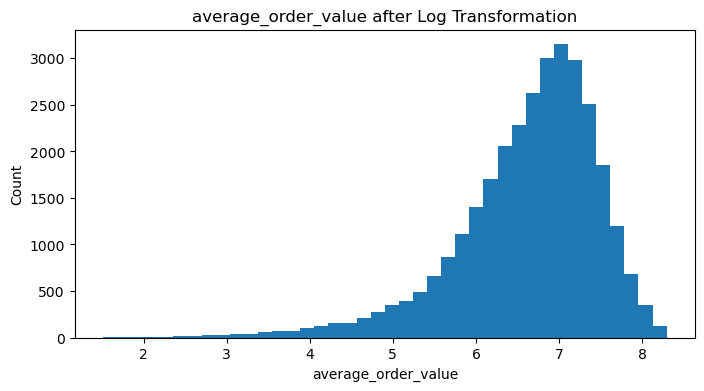

In [144]:
import matplotlib.pyplot as plt

for col in log_features:
    plt.figure(figsize=(8, 4))
    plt.hist(customer_df_log[col], bins=40)
    plt.title(f"{col} after Log Transformation")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [145]:
customer_df.head()

,total_quantity,total_spent,total_orders,category_prefer,recency,average_order_value
customer_id,,,,,,
40873,26,12955.0655,7,Home Decor,102,1850.723643
27889,23,12462.8120,6,Electronics,137,2077.135333
15933,24,11917.5365,6,Electronics,17,1986.256083
34270,25,11654.9850,5,Accessories,13,2330.997000
24933,19,11362.3775,6,Footwear,110,1893.729583


In [146]:
from sklearn.preprocessing import StandardScaler
scaled_cols=customer_df_log.columns
scaler=StandardScaler()
customer_df_scaled=scaler.fit_transform(customer_df_log[scaled_cols])

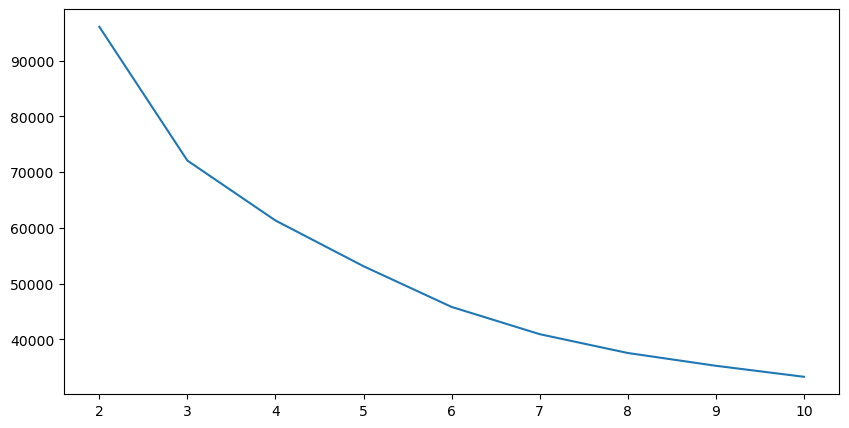

In [148]:
from sklearn.cluster import KMeans
interi=[]
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(customer_df_scaled)
    interi.append(kmeans.inertia_)
plt.figure(figsize=(10,5))
plt.plot(range(2,11),interi)
plt.show()

In [149]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
customer_df['cluster']=kmeans.fit_predict(customer_df_scaled)

In [150]:
customer_df.head(10)

,total_quantity,total_spent,total_orders,category_prefer,recency,average_order_value,cluster
customer_id,,,,,,,
40873,26,12955.0655,7,Home Decor,102,1850.723643,1
27889,23,12462.8120,6,Electronics,137,2077.135333,1
15933,24,11917.5365,6,Electronics,17,1986.256083,1
34270,25,11654.9850,5,Accessories,13,2330.997000,1
24933,19,11362.3775,6,Footwear,110,1893.729583,1
28605,24,11282.7165,7,Fashion,174,1611.816643,1
16198,22,10957.5540,5,Beauty,237,2191.510800,1
33354,24,10696.6490,6,Electronics,196,1782.774833,1
43578,17,10245.5450,4,Accessories,258,2561.386250,1


In [151]:
customer_df[['recency','total_orders','total_spent','total_quantity','average_order_value','cluster']].groupby('cluster').mean()

,recency,total_orders,total_spent,total_quantity,average_order_value
cluster,,,,,
0,434.517929,1.442044,1692.556897,4.577894,1270.806440
1,175.422811,2.995950,3205.300756,9.492497,1104.896659
2,421.124930,1.187746,352.146502,2.404225,307.288490


In [152]:
customer_df['cluster'].value_counts()

cluster
0    13191
1    10863
2     7100
Name: count, dtype: int64

In [154]:
customer_df['cluster']=customer_df['cluster'].map({1:'Best Customers',0:'At-Risk High-Value',2:'Low-Value Customers'})

In [155]:
customer_df.head(10)

,total_quantity,total_spent,total_orders,category_prefer,recency,average_order_value,cluster
customer_id,,,,,,,
40873,26,12955.0655,7,Home Decor,102,1850.723643,Best Customers
27889,23,12462.8120,6,Electronics,137,2077.135333,Best Customers
15933,24,11917.5365,6,Electronics,17,1986.256083,Best Customers
34270,25,11654.9850,5,Accessories,13,2330.997000,Best Customers
24933,19,11362.3775,6,Footwear,110,1893.729583,Best Customers
28605,24,11282.7165,7,Fashion,174,1611.816643,Best Customers
16198,22,10957.5540,5,Beauty,237,2191.510800,Best Customers
33354,24,10696.6490,6,Electronics,196,1782.774833,Best Customers
43578,17,10245.5450,4,Accessories,258,2561.386250,Best Customers


In [157]:
customer_df.to_csv(r'C:\Users\workstation\Desktop\jdk\modeling\data.csv')